In [2]:
import pandas as pd
import numpy as np
import os
import glob
import xgboost as xgb
from scipy.stats import qmc  # Latin Hypercube Sampling
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score, mean_absolute_error

### ---------------------------------------------------------
### Step 1: 데이터 로드 및 통합 (Dataset 1 & 2 합치기)
### ---------------------------------------------------------

In [3]:
# 마스터 파일 로드
master_df = pd.read_csv('D:\AI_Study\GitHub\Battery\Master_DOE_1200.csv')

# 두 개의 압축 해제 폴더 경로 (사용자 환경에 맞춰 수정)
folders = ['D:/AI_Study/GitHub/Battery/데이터셋/', 'D:/AI_Study/GitHub/Battery/데이터셋 2/']
p_columns = ['P1', 'P2', 'P3', 'P4', 'P5', 'P6']

processed_list = []
print("데이터 통합 및 특징 추출 시작...")

데이터 통합 및 특징 추출 시작...


In [4]:
for i, row in master_df.iterrows():
    found = False
    file_name = f'ML_DATA_Extract_Row_{i}.csv'
    
    # 두 폴더 중 파일이 존재하는 곳을 탐색
    for folder in folders:
        file_path = os.path.join(folder, file_name)
        if os.path.exists(file_path):
            df_detail = pd.read_csv(file_path)
            df_detail.columns = df_detail.columns.str.strip()
            
            # 지표 추출: Die_SY_Max의 절댓값 중 최대값 (Max Peak)
            target_val = df_detail['Die_SY_Max'].abs().max()
            
            # 특징 결합
            features = row.to_dict()
            features['Target_Y'] = target_val
            processed_list.append(features)
            found = True
            break # 파일을 찾으면 다음 행으로

df_final = pd.DataFrame(processed_list)
print(f"✅ 통합 완료: 총 {len(df_final)}개의 데이터를 확보했습니다.")

✅ 통합 완료: 총 542개의 데이터를 확보했습니다.


### ---------------------------------------------------------
### Step 2: 기초 EDA (상관관계 및 분포 확인)
### ---------------------------------------------------------

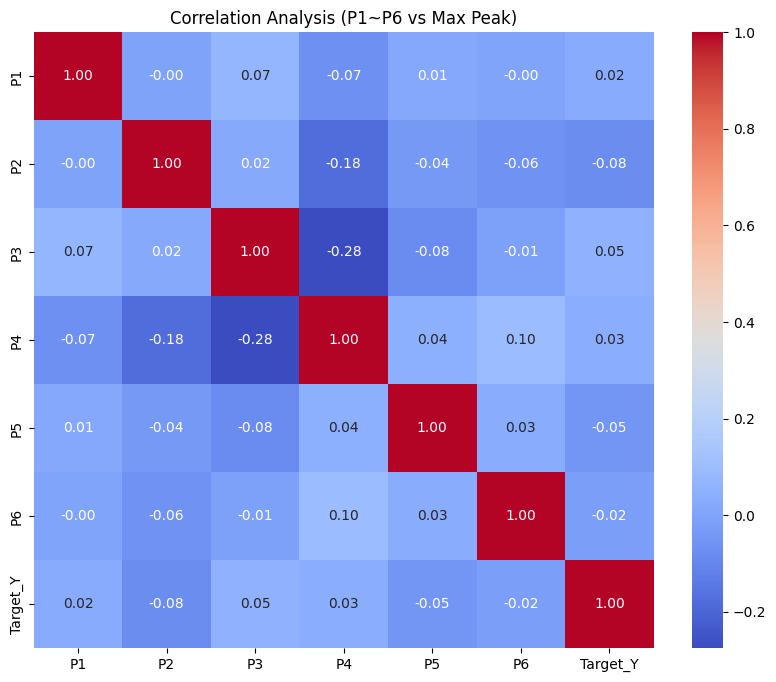

In [5]:
plt.figure(figsize=(10, 8))
sns.heatmap(df_final.corr(), annot=True, cmap='coolwarm', fmt='.2f')
plt.title("Correlation Analysis (P1~P6 vs Max Peak)")
plt.show()

### ---------------------------------------------------------
### Step 3: XGBoost 대리 모델 학습
### ---------------------------------------------------------

In [6]:
X = df_final[p_columns]
y = df_final['Target_Y']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

model = xgb.XGBRegressor(n_estimators=1000, learning_rate=0.05, max_depth=6, random_state=42)
model.fit(X_train, y_train)

y_pred = model.predict(X_test)
print(f"📈 모델 성능 (R2 Score): {r2_score(y_test, y_pred):.4f}")

📈 모델 성능 (R2 Score): -0.3413


### ---------------------------------------------------------
### Step 4: LHS 기법을 이용한 범위 내 가상 데이터 10만 개 생성
### ---------------------------------------------------------

In [8]:
print("\nLHS(Latin Hypercube Sampling) 적용 중...")
n_virtual = 100000

# 1. 정의된 탐색 범위(Boundary) 추출
p_min = df_final[p_columns].min().values
p_max = df_final[p_columns].max().values

# 2. LHS 샘플러 초기화 (차원 = 6)
sampler = qmc.LatinHypercube(d=len(p_columns), seed=42)
sample_raw = sampler.random(n=n_virtual)

# 3. [수정됨] 직접 스케일링 (0~1 사이의 값을 실제 p_min ~ p_max 범위로 변환)
# 공식: 결과 = min + (sample * (max - min))
virtual_samples = p_min + sample_raw * (p_max - p_min)

# 4. 데이터프레임 변환
df_virtual = pd.DataFrame(virtual_samples, columns=p_columns)

# 5. 대리 모델을 통한 예측
df_virtual['Predicted_Y'] = model.predict(df_virtual)
print("✅ 10만 개의 가상 데이터 생성 완료.")


LHS(Latin Hypercube Sampling) 적용 중...
✅ 10만 개의 가상 데이터 생성 완료.


### ---------------------------------------------------------
### Step 5: 최종 시각화
### ---------------------------------------------------------

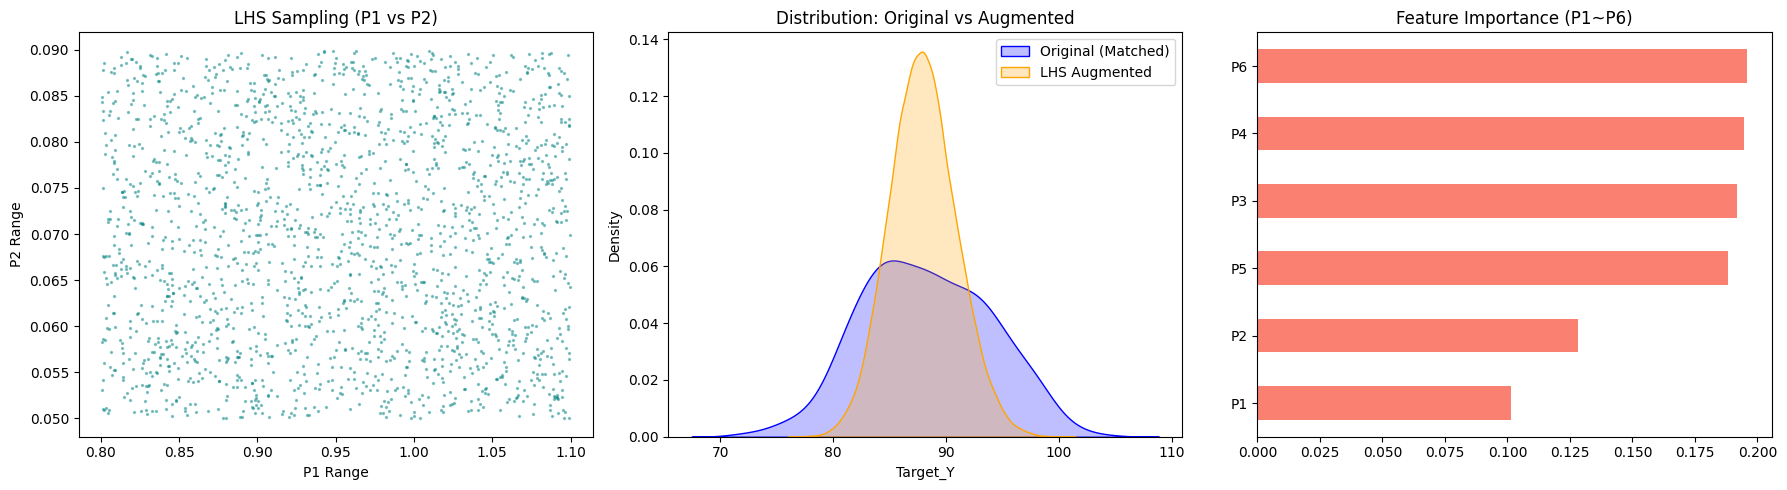

In [9]:
plt.figure(figsize=(18, 5))

# 5-1. LHS 샘플링 분포 (P1 vs P2 예시)
plt.subplot(1, 3, 1)
plt.scatter(df_virtual['P1'].head(2000), df_virtual['P2'].head(2000), s=2, alpha=0.4, color='teal')
plt.title("LHS Sampling (P1 vs P2)")
plt.xlabel("P1 Range")
plt.ylabel("P2 Range")

# 5-2. 원본 데이터 vs 가상 데이터 분포 비교
plt.subplot(1, 3, 2)
sns.kdeplot(df_final['Target_Y'], label='Original (Matched)', fill=True, color='blue')
sns.kdeplot(df_virtual['Predicted_Y'], label='LHS Augmented', fill=True, color='orange')
plt.title("Distribution: Original vs Augmented")
plt.legend()

# 5-3. 변수 중요도 (어떤 Parameter가 Max Peak에 영향을 주는가)
plt.subplot(1, 3, 3)
feat_importances = pd.Series(model.feature_importances_, index=p_columns).sort_values()
feat_importances.plot(kind='barh', color='salmon')
plt.title("Feature Importance (P1~P6)")

plt.tight_layout()
plt.show()